# Example 4 - Laser and Raman Photon Path Tracing 

Monte Carlo simulations track individual photon packets as they propagate
through a turbid medium — scattering, converting, and eventually either
escaping or being absorbed. This notebook lets you visualise those trajectories
directly.

---

## What this simulation models

The NMC Raman kernel launches photons into a tissue-like scattering volume of width
$w$ (mm). Each photon undergoes:

- **Elastic scattering** — direction changes governed by the Henyey–Greenstein
  phase function with anisotropy factor $g$
- **Raman scattering** — spontaneous inelastic event, probability `raman_prob`
  per step; converts a Laser photon (type 1) into a Raman photon (type 2)
- **Stimulated Raman scattering (SRS)** — probability `stim_raman_prob`;
  produces an SRS photon (type 3)
- **Absorption** — governed by $\mu_a$; terminates the photon packet

The simulation volume is a cube $[-w,\,w]\times[-w,\,w]\times[0,\,w]$ mm,
where $z = 0$ is the illuminated (top) surface. Photons are focused at depth
$z_\text{focus}$ through a lens of numerical aperture NA.

---

## Photon types

| Type | Label | Physical meaning |
|------|-------|-----------------|
| 1 | **Laser** | Incident excitation photon — has not undergone inelastic scattering |
| 2 | **Raman** | Spontaneous Raman-converted photon |
| 3 | **SRS** | Stimulated Raman-scattered photon |
| 0 | *(termination)* | Final row of each trajectory; z-coordinate encodes the fate |

A trajectory **ends** when `type == 0`. The terminal z-coordinate tells us the
photon's fate:

$$
\text{exit state} = \begin{cases}
\text{top}      & z_\text{end} \approx 0      \quad\text{(back-scattered)}\\
\text{bottom}   & z_\text{end} \approx w      \quad\text{(transmitted)}\\
\text{absorbed} & \text{otherwise}
\end{cases}
$$

The **photon type** assigned to a trajectory is the last non-zero type seen
before termination — i.e. what the photon *was* when it exited or was absorbed.

---

## Output files used

| File pattern | Contents |
|---|---|
| `photons_data_mus-*_NA-*_zf-*.csv` | Full photon trajectories: position, time, weight, type at every sampled step |

---

## Key parameters

| Parameter | Symbol | Unit | Effect |
|-----------|--------|------|--------|
| `mu_s` | $\mu_s$ | mm⁻¹ | Scattering coefficient — higher → shorter mean free path |
| `mu_a` | $\mu_a$ | mm⁻¹ | Absorption coefficient |
| `g` | $g$ | — | Anisotropy: 0 = isotropic, 1 = fully forward |
| `zfocus` | $z_f$ | mm | Focal depth of the beam |
| `numerial_aperture` | NA | — | Collection / focusing aperture |
| `raman_prob` | — | — | Per-step probability of spontaneous Raman conversion |
| `width` | $w$ | mm | Half-width of the simulation volume |

---

## Workflow

1. Set simulation parameters and path to the NMC executable
2. Write config files; check whether outputs already exist
3. Run the simulation (skipped automatically if output is found)
4. Load trajectory data into two tables: `df_raw` and `df_summary`
5. Draw a random sample of complete trajectories for plotting
6. Static plot — depth vs time ($z$–$t$ traces)
7. Static plot — depth vs radial distance ($z$–$r$ traces)
8. Interactive 3-D animation — propagation of a chosen photon type


> **Tip — re-running:** if you change any parameter in Cell 2, delete the
> existing `photons_data_*.csv` from the build folder so Cell 3 triggers a
> fresh simulation run.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# ── make nmc_utils importable as `nmc` ───────────────────────────────────────
NOTEBOOK_DIR = Path("/Users/vladykilya/Documents/Xcode/raman2nmc/NMC-samples") #Path.cwd()
sys.path.insert(0, str(NOTEBOOK_DIR))
import nmc_utils as nmc

nmc.set_paper_style()
print("nmc_utils loaded")

nmc_utils loaded


In [ ]:
# ── paths ─────────────────────────────────────────────────────────────────────
# Default: relative path from NMC-samples/ to the build folder.
# Override with an absolute Path if your build lives elsewhere:
#   EXE_DIR = Path("/Users/you/wherever/NMC/Build/Products/Debug")
EXE_DIR  = (NOTEBOOK_DIR / "../NMC/Build/Products/Debug").resolve()
EXE_NAME = "nmc"
EXE_PATH = EXE_DIR / EXE_NAME

# ── simulation parameters ─────────────────────────────────────────────────────
PARAMS = dict(
    fname                  = "example",
    width                  = 5.0,    # mm  — simulation box full-width
    Nx                     = 100,
    Ny                     = 100,
    Nz                     = 100,
    mu_a                   = 0.1,    # mm-1  absorption coefficient
    mu_s                   = 10.0,   # mm-1  scattering coefficient
    g                      = 0.6,    #       anisotropy factor
    index_of_refraction    = 1.6,
    zfocus                 = 1.0,    # mm  focal depth
    numerial_aperture      = 1.0,    # -   NA
    laser_beam_radius      = 0.05,   # mm
    laser_beam_pulse_width = 5.0,    # ps
    laser_beam_pulse_delay = 15.0,   # ps
    raman_prob             = 0.05,
    stim_raman_prob        = 0.1,
)

# ── plotting controls ─────────────────────────────────────────────────────────
N_TRAJ_PLOT   = 5          # trajectories per type for static plots
TYPES_PLOT    = [1, 2]   # photon types to include
SAVE_FIGS     = True
FIGS_DIR      = NOTEBOOK_DIR / "figs"
FIGS_DIR.mkdir(exist_ok=True)

print(f"EXE  : {EXE_PATH}")
print(f"FIGS : {FIGS_DIR}")

EXE  : /Users/vladykilya/Documents/Xcode/raman2nmc/NMC/Build/Products/Debug/nmc
FIGS : /Users/vladykilya/Documents/Xcode/raman2nmc/NMC-samples/figs


In [31]:
# human-readable config → notebook folder
# machine-readable .mci → build folder (next to the exe)
mci_path, cfg_path = nmc.init_config_file(
    cfg_dir=NOTEBOOK_DIR,
    mci_dir=EXE_DIR,
    **PARAMS,
)
print(f"CFG written : {cfg_path}")
print(f"MCI written : {mci_path}")

# ── derive expected output filename from params ───────────────────────────────
mus = PARAMS["mu_s"]
NA  = PARAMS["numerial_aperture"]
zf  = PARAMS["zfocus"]
expected_output = f"photons_data_mus-{mus:.2f}_NA-{NA:.2f}_zf-{zf:.2f}.csv"

existing = nmc.find_outputs(expected_output, workdir=EXE_DIR)
if existing:
    print(f"\nOutput already exists : {existing[0].name}")
    print("Skipping simulation — delete the file to re-run.")
    RUN_NEEDED = False
else:
    print(f"\nNo output found for : {expected_output}")
    print("Simulation will run in Cell 4.")
    RUN_NEEDED = True

CFG written : /Users/vladykilya/Documents/Xcode/raman2nmc/NMC-samples/config file example.txt
MCI written : /Users/vladykilya/Documents/Xcode/raman2nmc/NMC/Build/Products/Debug/example_H.mci

Output already exists : photons_data_mus-10.00_NA-1.00_zf-1.00.csv
Skipping simulation — delete the file to re-run.


In [32]:
if RUN_NEEDED:
    nmc.run(
        exe_path=EXE_PATH,
        mci_name=PARAMS["fname"],
        workdir=EXE_DIR,
    )
else:
    print("Skipped (output already exists).")

Skipped (output already exists).


In [5]:
photons_csv = EXE_DIR / expected_output

df_raw, df_summary = nmc.load_photons(
    photons_csv,
    z_bottom=PARAMS["width"],
    types_of_interest=tuple(TYPES_PLOT),
)

# attach readable label columns
df_raw["type_label"]     = df_raw["type"].map(nmc.TYPE_LABELS)
df_summary["type_label"] = df_summary["prev_type"].map(nmc.TYPE_LABELS)

print(f"\ndf_raw    : {df_raw.shape}")
print(f"df_summary: {df_summary.shape}")

[load_photons] Total rows       : 10,879,252
[load_photons] Unique markers   : 100,000
[load_photons] Summarised       : 100,000  (after type filter: [1, 2])

[load_photons] Exit state counts (post-filter):
bottom      42551
top         40838
absorbed    16611

[load_photons] prev_type counts (post-filter):
1    94587
2     5413

df_raw    : (10879252, 8)
df_summary: (100000, 8)


In [6]:
rng = np.random.default_rng(seed=5)

SHOW_ABSORBED = False  # set True to also include absorbed trajectories

exit_filter = ["top", "bottom"]
if SHOW_ABSORBED:
    exit_filter.append("absorbed")

sampled_markers = []
for ptype in TYPES_PLOT:
    pool = df_summary.loc[
        (df_summary["prev_type"] == ptype)
        & (df_summary["exit_state"].isin(exit_filter)),
        "marker",
    ].values
    n = min(N_TRAJ_PLOT, len(pool))
    sampled_markers.extend(rng.choice(pool, size=n, replace=False).tolist())

df_sample = df_raw[df_raw["marker"].isin(sampled_markers)].copy()

# propagation rows only — exclude type-0 termination points from line plots
df_prop = df_sample.copy()
df_prop["r"] = np.sqrt(df_prop["x"]**2 + df_prop["y"]**2)

# attach trajectory-level info from df_summary for plotting
marker_info = df_summary.set_index("marker")[["prev_type", "exit_state"]]
df_prop = df_prop.join(marker_info, on="marker")

# ── summary ───────────────────────────────────────────────────────────────────
sampled = df_summary[df_summary["marker"].isin(sampled_markers)]
print(f"Sampled {len(sampled)} trajectories  ->  {len(df_prop)} propagation rows\n")
print(sampled.groupby(["type_label", "exit_state"]).size()
      .rename("n_traj").reset_index().to_string(index=False))

Sampled 10 trajectories  ->  1372 propagation rows

type_label exit_state  n_traj
     Laser     bottom       2
     Laser        top       3
     Raman     bottom       4
     Raman        top       1


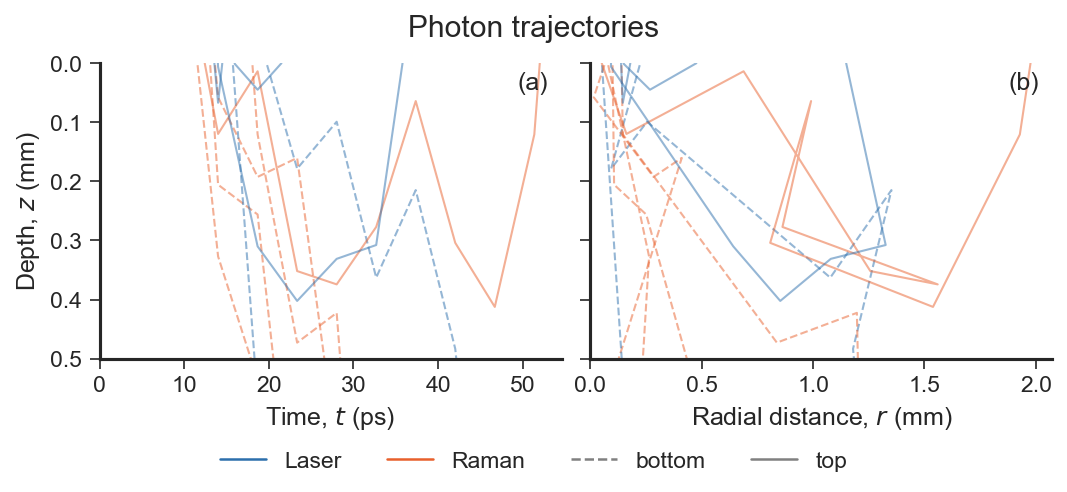

In [26]:
from matplotlib.lines import Line2D

EXIT_LINESTYLE = {"top": "-", "bottom": "--", "absorbed": ":"}
EXIT_LABELS    = {"top": "top", "bottom": "bottom", "absorbed": "absorbed"}

fig, (ax_zt, ax_zr) = plt.subplots(1, 2, figsize=(7.0, 3.2), sharey=True,layout="constrained")

for ax, xcol, xlabel, panel in [
    (ax_zt, "t", r"Time, $t$ (ps)",            "(a)"),
    (ax_zr, "r", r"Radial distance, $r$ (mm)", "(b)"),
]:
    for _, traj in df_prop.groupby("marker"):
        ptype  = traj["prev_type"].iloc[0]
        estate = traj["exit_state"].iloc[0]
        ax.plot(
            traj[xcol], traj["z"],
            color=nmc.TYPE_COLORS[ptype],
            linestyle=EXIT_LINESTYLE.get(estate, "-"),
            alpha=0.5, linewidth=1.0,
        )
    ax.set_xlabel(xlabel)
    ax.text(0.97, 0.97, panel, transform=ax.transAxes,
            va="top", ha="right", fontsize=plt.rcParams["font.size"])
    sns.despine(ax=ax)

ax_zt.set_ylabel(r"Depth, $z$ (mm)")
ax_zt.invert_yaxis()
ax_zt.set_ylim(PARAMS["width"], 0)   # crop to layer [0, w], z=0 at top
ax_zt.set_xlim(left = 0)   
ax_zr.set_xlim(left = 0)  


# ── legend with Line2D custom handles (same pattern as example6) ──────────────
active_exits = sorted(df_prop["exit_state"].unique())
legend_handles = [
    Line2D([0], [0], color=nmc.TYPE_COLORS[pt], lw=1.2,
           label=nmc.TYPE_LABELS[pt])
    for pt in TYPES_PLOT
] + [
    Line2D([0], [0], color="grey", ls=EXIT_LINESTYLE[es], lw=1.2,
           label=EXIT_LABELS[es])
    for es in active_exits if es in EXIT_LINESTYLE
]

fig.legend(
    handles=legend_handles,
    loc="outside lower center",
    ncol=len(legend_handles),
    frameon=False,
)

fig.suptitle("Photon trajectories")

if SAVE_FIGS:
    fig.savefig(FIGS_DIR / "ex4_trajectories.pdf", bbox_inches="tight")
plt.show()

In [12]:
# ── user controls for animation ───────────────────────────────────────────────
N_TRAJ_ANIM = 100     # max trajectories per type (keep <200 for performance)
N_FRAMES    = 50     # time frames
N_TRAIL     = 5      # trail fades over this many frames

width = PARAMS["width"]
w = width

# ── 1. sample & resample trajectories ─────────────────────────────────────────
rng_anim = np.random.default_rng(seed=0)

t_max_all = df_raw.loc[df_raw["type"] != 0, "t"].max()
t_edges   = np.linspace(0.0, t_max_all, N_FRAMES + 1)
t_frames  = t_edges[1:]
t_mids    = 0.5 * (t_edges[:-1] + t_edges[1:])

resampled = {}
for atype in [1, 2]:
    pool = df_summary.loc[df_summary["prev_type"] == atype, "marker"].values
    if len(pool) == 0:
        resampled[atype] = []
        continue
    chosen = rng_anim.choice(pool, size=min(N_TRAJ_ANIM, len(pool)), replace=False)

    pos_list = []
    for m in chosen:
        seg = df_raw[(df_raw["marker"] == m) & (df_raw["type"] == atype)]
        if len(seg) < 2:
            continue
        seg = seg.sort_values("t")
        ts = seg["t"].values

        pos = np.full((N_FRAMES, 3), np.nan)
        mask = (t_frames >= ts[0]) & (t_frames <= ts[-1])
        if mask.any():
            for k, col in enumerate(["x", "y", "z"]):
                pos[mask, k] = np.interp(t_frames[mask], ts, seg[col].values)
        pos_list.append(pos)
    resampled[atype] = pos_list

print(f"Resampled: Laser = {len(resampled[1])}, Raman = {len(resampled[2])}")

# ── 2. trail helpers ──────────────────────────────────────────────────────────
_trail_alpha = [round(1.0 - k * 0.8 / (N_TRAIL - 1), 2) for k in range(N_TRAIL)]

def _scene_traces(pos_list, fi, color, sc):
    """N_TRAIL fading trail-line traces + 1 head-marker trace."""
    traces = []
    for age in range(N_TRAIL):
        i1, i0 = fi - age, fi - age - 1
        lx, ly, lz = [], [], []
        if i1 >= 0 and i0 >= 0:
            for pos in pos_list:
                p0, p1 = pos[i0], pos[i1]
                if not (np.isnan(p0[0]) or np.isnan(p1[0])):
                    lx += [p0[0], p1[0], None]
                    ly += [p0[1], p1[1], None]
                    lz += [p0[2], p1[2], None]
        traces.append(go.Scatter3d(
            x=lx, y=ly, z=lz,
            mode="lines+markers",
            line=dict(color=color, width=3),
            marker=dict(size=1.2, color=color),
            opacity=_trail_alpha[age],
            showlegend=False, hoverinfo="skip", scene=sc,
        ))
    # head marker — larger
    hx, hy, hz = [], [], []
    if fi >= 0:
        for pos in pos_list:
            if not np.isnan(pos[fi, 0]):
                hx.append(pos[fi, 0]); hy.append(pos[fi, 1]); hz.append(pos[fi, 2])
    traces.append(go.Scatter3d(
        x=hx, y=hy, z=hz, mode="markers",
        marker=dict(size=4, color=color, opacity=0.9),
        showlegend=False, hoverinfo="skip", scene=sc,
    ))
    return traces

# ── 3. box wireframe ─────────────────────────────────────────────────────────
_bx = [-w,w,None, w,w,None, w,-w,None, -w,-w,None,
       -w,-w,None, w,w,None, w,w,None, -w,-w,None,
       -w,w,None, w,-w,None, -w,-w,None, w,w,None]
_by = [-w,-w,None, -w,w,None, w,w,None, w,-w,None,
       -w,-w,None, -w,-w,None, w,w,None, w,w,None,
       -w,-w,None, -w,-w,None, w,w,None, w,w,None]
_bz = [w,w,None, w,w,None, w,w,None, w,w,None,
       w,0,None, w,0,None, w,0,None, w,0,None,
       0,0,None, 0,0,None, 0,0,None, 0,0,None]

def _box(sc):
    return go.Scatter3d(
        x=_bx, y=_by, z=_bz, mode="lines",
        line=dict(color="lightgrey", width=1),
        showlegend=False, hoverinfo="skip", scene=sc,
    )

# ── 4. assemble traces for one frame ─────────────────────────────────────────
def _all_traces(fi):
    return (
        [_box("scene")]
        + _scene_traces(resampled[1], fi, nmc.TYPE_COLORS[1], "scene")
        + [_box("scene2")]
        + _scene_traces(resampled[2], fi, nmc.TYPE_COLORS[2], "scene2")
    )

# ── 5. build frames ──────────────────────────────────────────────────────────
plotly_frames = [
    go.Frame(data=_all_traces(fi), name=str(fi))
    for fi in range(N_FRAMES)
]

# ── 6. layout + figure ───────────────────────────────────────────────────────
_sc = dict(
    xaxis=dict(title="x (mm)", range=[-w, w], backgroundcolor="white",
               gridcolor="#dddddd", showbackground=True),
    yaxis=dict(title="y (mm)", range=[-w, w], backgroundcolor="white",
               gridcolor="#dddddd", showbackground=True),
    zaxis=dict(title="z (mm)", range=[w, 0], backgroundcolor="white",
               gridcolor="#dddddd", showbackground=True),
    aspectmode="cube",
    bgcolor="white",
    camera=dict(eye=dict(x=1.4, y=1.4, z=0.6),
                center=dict(x=0.2, y=0, z=-0.1)),
)

fig_anim = go.Figure(
    data=_all_traces(0),
    layout=go.Layout(
        scene =dict(**_sc, domain=dict(x=[0, 0.48], y=[0.1, 1])),
        scene2=dict(**_sc, domain=dict(x=[0.52, 1.0], y=[0.1, 1])),
        annotations=[
            # scene titles
            dict(text="Laser", x=0.25, y=1.0, xref="paper", yref="paper",
                showarrow=False, font=dict(size=16)),
            dict(text="Raman", x=0.83, y=1.0, xref="paper", yref="paper",
                showarrow=False, font=dict(size=16)),
        ],
        updatemenus=[dict(
            type="buttons", 
            direction="left", showactive=False,
            x=0.1, y=0.0, xanchor="right", yanchor="top",
            pad=dict(r=0, t=45),
            buttons=[
                dict(label="▶", method="animate",
                     args=[None, dict(
                         frame=dict(duration=120, redraw=True),
                         fromcurrent=True,
                         transition=dict(duration=0))]),
                dict(label="⏸", method="animate",
                     args=[[None], dict(
                         frame=dict(duration=0, redraw=False),
                         mode="immediate")]),
            ],
        )],
        sliders=[dict(
            steps=[
                dict(method="animate",
                     args=[[str(fi)], dict(
                         mode="immediate",
                         frame=dict(duration=0, redraw=True),
                         transition=dict(duration=0))],
                     label=f"{t_mids[fi]:.0f}")
                for fi in range(N_FRAMES)
            ],
            x=0.15, len=0.85,
            y=0.0, yanchor="top",
            currentvalue=dict(prefix="t = ", suffix=" ps", font=dict(size=11)),
            transition=dict(duration=0),
        )],
        margin=dict(l=0, r=20, b=100, t=10),
        paper_bgcolor="white",
        showlegend=False,
    ),
    frames=plotly_frames,
)
fig_anim.show()

if SAVE_FIGS:
    fig_anim.write_html(FIGS_DIR / "ex4_animation.html", auto_play=False)
    print(f"Animation saved : {FIGS_DIR / 'ex4_animation.html'}")

Resampled: Laser = 100, Raman = 72


Animation saved : /Users/vladykilya/Documents/Xcode/raman2nmc/NMC-samples/figs/ex4_animation.html
